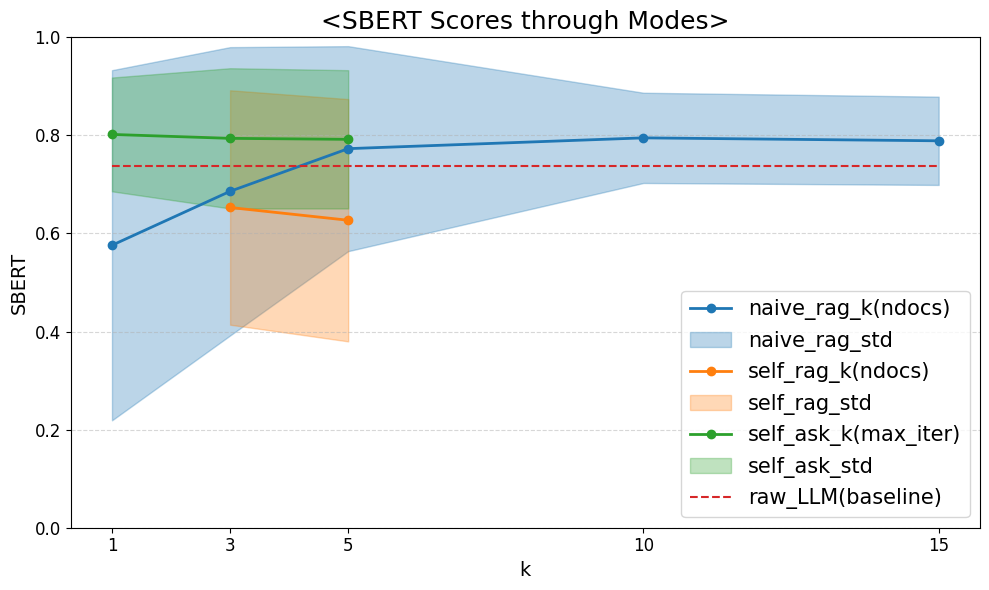

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Excel 파일에서 mean/std 시트 불러오기
file_path = 'soil/soil_gemini/summary.xlsx'  # 실제 경로로 맞춰주세요
df_mean = pd.read_excel(file_path, sheet_name='mean', index_col=0)
df_std  = pd.read_excel(file_path, sheet_name='std',  index_col=0)

# 2) 각 모드별 데이터 추출
modes_data = {}
for prefix in ['partial', 'adaptive', 'selfask']:
    modes = sorted(
        [m for m in df_mean.index if m.startswith(prefix + '_')],
        key=lambda x: int(x.split('_')[1])
    )
    ks    = np.array([int(m.split('_')[1]) for m in modes])
    means = np.array(df_mean.loc[modes, 'sbert'])
    stds  = np.array(df_std .loc[modes, 'sbert'])
    modes_data[prefix] = (ks, means, stds)

# 3) raw_llm baseline 하나만
baseline_raw = df_mean.at['raw_llm', 'sbert']

# 4) 그리기
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(10, 6))

for i, prefix in enumerate(['partial', 'adaptive', 'selfask']):
    ks, means, stds = modes_data[prefix]
    color = colors[i]
    # 4.1) 메인 선 + 점
    plt.plot(ks, means, marker='o', linewidth=2, color=color, label=f'{prefix}_k')
    # 4.2) 반투명 밴드 (mean±std)
    plt.fill_between(
        ks,
        means - stds,
        means + stds,
        color=color,
        alpha=0.3
    )

# raw_llm 수평 dashed line
all_ks = sorted({k for data in modes_data.values() for k in data[0]})
plt.hlines(
    y=baseline_raw,
    xmin=min(all_ks), xmax=max(all_ks),
    linestyles='--',
    label='raw_llm',
    color=colors[len(modes_data)]
)

# 5) 스타일링
plt.title('<SBERT Scores through Modes>', fontsize=18)
plt.xlabel('k', fontsize=14)
plt.ylabel('SBERT', fontsize=14)
plt.xticks(all_ks, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(['naive_rag_k(ndocs)','naive_rag_std','self_rag_k(ndocs)','self_rag_std',
            'self_ask_k(max_iter)','self_ask_std','raw_LLM(baseline)'], loc='lower right', fontsize=15)
plt.tight_layout()
plt.show()
